# py-Slingshot tutorial — Y-shaped synthetic

End-to-end: cluster a Y-shaped 2-D fixture, run Slingshot, visualise.

## 1. Setup

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('..').resolve()))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import pyslingshot
print(f'pyslingshot {pyslingshot.__version__}')

pyslingshot 0.1.0


## 2. Build Y-shaped data + cluster

In [2]:
rng = np.random.RandomState(42)
n = 100
t_stem = np.linspace(0, 1, n); stem = np.column_stack([t_stem*4-2, np.zeros(n)]) + rng.normal(0, 0.12, (n,2))
t_b1   = np.linspace(0, 1, n); b1   = np.column_stack([2+t_b1*2, t_b1*2]) + rng.normal(0, 0.12, (n,2))
t_b2   = np.linspace(0, 1, n); b2   = np.column_stack([2+t_b2*2, -t_b2*2]) + rng.normal(0, 0.12, (n,2))
X = np.vstack([stem, b1, b2])
cl = (KMeans(n_clusters=5, random_state=42, n_init=10).fit(X).labels_ + 1).astype(str)
print('X:', X.shape, 'clusters:', sorted(set(cl)))

X: (300, 2) clusters: ['1', '2', '3', '4', '5']


## 3. Run end-to-end Slingshot

In [3]:
sr = pyslingshot.slingshot(X, cl, start_cluster=cl[np.argmin(X[:,0])])
print('lineages:', sr.lineages)
print('pseudotime:', sr.pseudotime.shape)
print('curves:', [c.shape for c in sr.curves])

lineages: [['2', '5', '4', '1'], ['2', '5', '4', '3']]
pseudotime: (300, 2)
curves: [(300, 2), (300, 2)]


/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


## 4. Visualise with plot_slingshot

/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/ggplot2_py/layer.py:932: UserWarning: Ignoring unknown parameters: `size`
  cli_warn(
/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/ggplot2_py/layer.py:932: UserWarning: Ignoring unknown parameters: `size`
  cli_warn(


Saving 6 x 4 in image to slingshot_demo.png


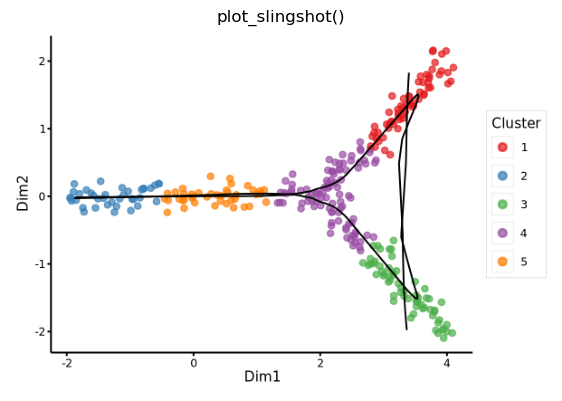

In [4]:
from ggplot2_py import ggsave
p = pyslingshot.plot_slingshot(sr)
ggsave('slingshot_demo.png', plot=p, width=6, height=4, dpi=100)
from PIL import Image
fig, ax = plt.subplots(figsize=(7, 5))
ax.imshow(Image.open('slingshot_demo.png')); ax.axis('off'); ax.set_title('plot_slingshot()'); plt.show()

## 5. plot_pseudotime per lineage

Saving 6 x 4 in image to slingshot_pt_0.png


Saving 6 x 4 in image to slingshot_pt_1.png


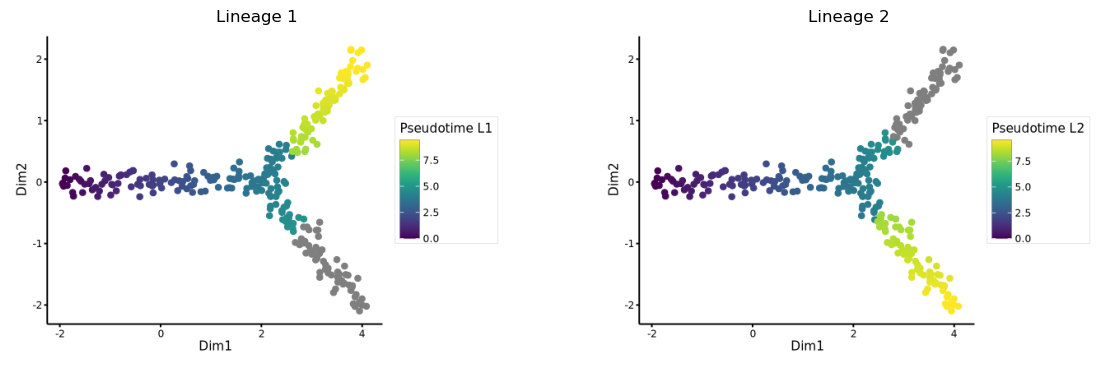

In [5]:
for li in range(sr.pseudotime.shape[1]):
    p2 = pyslingshot.plot_pseudotime(sr, lineage=li)
    ggsave(f'slingshot_pt_{li}.png', plot=p2, width=6, height=4, dpi=100)
fig, axes = plt.subplots(1, sr.pseudotime.shape[1], figsize=(7*sr.pseudotime.shape[1], 5))
if sr.pseudotime.shape[1] == 1: axes = [axes]
for li, ax in enumerate(axes):
    ax.imshow(Image.open(f'slingshot_pt_{li}.png')); ax.axis('off'); ax.set_title(f'Lineage {li+1}')
plt.show()